---
title: BAB 2 Data Understanding
date: 2026-08-30
---

# BAB 2 Data Understanding

Tahap **Data Understanding** merupakan fase kedua dalam metodologi CRISP-DM yang bertujuan untuk menganalisis, mendokumentasikan, dan memverifikasi karakteristik data mentah (*raw data*) sebelum melangkah ke tahap rekayasa fitur (*Feature Engineering*) dan pemodelan prediktif (*Modeling*). Pada tahap ini, analisis dilakukan terhadap dataset polutan kualitas udara yang telah diekstrak dari platform geospasial *openEO Copernicus Atmosphere Monitoring Service (CAMS)* untuk wilayah Desa Mendenrejo, Kecamatan Kradenan, Kabupaten Blora.

---

## 2.1 Pengumpulan Data Awal (Data Collection)
Pengumpulan data awal dilakukan dengan memanfaatkan **openEO Python API** yang terintegrasi secara langsung dengan gudang data atmosfer *European Union (EU) Copernicus Programme / ECMWF CAMS*. Pemotongan spasial (*spatial subsetting*) dieksekusi secara otomatis berdasar batas poligon geospasial GeoJSON Desa Mendenrejo (Latitude: -7.2479, Longitude: 111.4440).

Rincian spesifikasi pengumpulan data awal disajikan sebagai berikut:
- **Sumber Data Utama**: Copernicus Atmosphere Monitoring Service (CAMS) via openEO API & Copernicus Data Space Ecosystem (CDSE).
- **Format File Penyimpanan**: Spreadsheet Tabular Microsoft Excel (`.xlsx`) berformat terstruktur.
- **Resolusi Temporal**: Data dicatat secara kontinu dengan frekuensi per jam (*hourly resolution*) selama 1 tahun penuh, terhitung mulai tanggal **28 Agustus 2025 pukul 00:00:00 hingga 28 Agustus 2026 pukul 23:00:00**.
- **Dimensi Dataset**: Dataset terdiri dari **8.784 baris** (sampel waktu per jam) dan **5 kolom utama** (`DATE_TIME`, `CO`, `NO2`, `SO2`, `CH4`).
- **Lokasi Penyimpanan Terpusat**: Dataset tersimpan secara terpusat pada direktori proyek `src/2-bussines_understanding/data/data_kualitas_udara_mendenrejo.xlsx` untuk menghindari duplikasi file.


---

## 2.2 Deskripsi Data (Data Description)
Guna memahami atribut dan karakteristik variabel pada dataset, disusun **Kamus Data (*Data Dictionary*)** yang merinci nama kolom, definisi operasional, tipe data (*data type*), satuan pengukuran, serta rentang/skala nilai teoritis dan aktual.

### Kamus Data Kualitas Udara Desa Mendenrejo

| Nama Kolom | Definisi Variabel / Deskripsi | Tipe Data | Satuan | Skala Nilai (Min - Max Aktual) |
| :--- | :--- | :--- | :--- | :--- |
| **`DATE_TIME`** | Stempel waktu perekaman data atmosfer (YYYY-MM-DD HH:mm:ss) | Waktu / *Datetime* | YYYY-MM-DD HH:mm:ss | 2025-08-28 00:00:00 s/d 2026-08-28 23:00:00 |
| **`CO`** | Konsentrasi Karbon Monoksida di lapisan atmosferik | Numerik (*Integer*) | μg/m³ | 103,00 – 1.869,00 |
| **`NO2`** | Konsentrasi Nitrogen Dioksida hasil pencemaran emisi | Numerik (*Float*) | μg/m³ | 0,00 – 92,10 |
| **`SO2`** | Konsentrasi Sulfur Dioksida hasil pembakaran atmosferik | Numerik (*Float*) | μg/m³ | 1,10 – 46,80 |
| **`CH4`** | Konsentrasi Metana (gas rumah kaca & emisi pertanian) | Numerik (*Integer*) | μg/m³ | 1.297,00 – 3.454,00 |

#### Karakteristik Struktur Data:
1. **`DATE_TIME`**: Merupakan variabel penanda waktu yang menjadi kunci indeks deret waktu (*time-series index*). Seluruh urutan baris tersusun secara kronologis tanpa ada lompatan waktu (*no time gap*).
2. **Variabel Polutan (`CO`, `NO2`, `SO2`, `CH4`)**: Berjenis variabel rasio kontinu (*continuous ratio variables*) non-negatif. Satuan kuantitatif diukur dalam mikrogram per meter kubik (μg/m³).


In [5]:
import os
import pandas as pd
import numpy as np

# Memuat dataset utama secara terpusat dari folder 'src/2-bussines_understanding/data/'
file_path = os.path.join("..", "2-bussines_understanding", "data", "data_kualitas_udara_mendenrejo.xlsx")

if not os.path.exists(file_path):
    file_path = os.path.join("src", "2-bussines_understanding", "data", "data_kualitas_udara_mendenrejo.xlsx")

df = pd.read_excel(file_path)

print("Status Memuat Dataset Terpusat:")
print(f"- Lokasi File    : {file_path}")
print(f"- Dimensi Data  : {df.shape[0]} baris x {df.shape[1]} kolom")
print(f"- Daftar Kolom  : {list(df.columns)}")
print("\nTampilan 5 Baris Pertama Dataset:")
print(df.head())


Status Memuat Dataset Terpusat:
- Lokasi File    : ..\2-bussines_understanding\data\data_kualitas_udara_mendenrejo.xlsx
- Dimensi Data  : 8784 baris x 5 kolom
- Daftar Kolom  : ['DATE_TIME', 'CO', 'NO2', 'SO2', 'CH4']

Tampilan 5 Baris Pertama Dataset:
             DATE_TIME   CO   NO2  SO2   CH4
0  2025-08-28 00:00:00  209  10.2  5.4  1392
1  2025-08-28 01:00:00  196   7.8  5.1  1374
2  2025-08-28 02:00:00  171   4.5  4.6  1352
3  2025-08-28 03:00:00  151   2.0  4.0  1336
4  2025-08-28 04:00:00  142   1.2  3.3  1331


### Penjelasan Hasil Pemuatan Data (Data Loading Analysis)
Berdasarkan hasil pembacaan file data di atas:
- Dataset berhasil dimuat secara terpusat dari folder `src/2-bussines_understanding/data/` dengan total **8.784 sampel waktu**. Jumlah ini sesuai tepat dengan perhitungan matematis durasi 1 tahun kabisat/penuh ($366 \text{ hari} \times 24 \text{ jam} = 8.784 \text{ baris}$).
- Struktur data bersih berformat matriks 5 kolom (`DATE_TIME`, `CO`, `NO2`, `SO2`, `CH4`), tanpa ada duplikasi folder atau duplikasi file data.


---

## 2.3 Eksplorasi Data (Exploratory Data Analysis / EDA)
Eksplorasi data dilakukan untuk memahami distribusi statistik dasar (penerapan ukuran pemusatan dan penyebaran data) serta hubungan antavariabel polutan secara visual.

### 2.3.1 Ringkasan Statistik Deskriptif
Metrik statistik deskriptif mencakup nilai Rataan (*Mean*), Median (Kuartil 2 / 50%), Standar Deviasi (*Std Dev*), Minimum, Maksimum, serta Kuartil 1 (25%) dan Kuartil 3 (75%).


In [6]:
# Menghitung statistik deskriptif untuk kolom polutan
stats_df = df[["CO", "NO2", "SO2", "CH4"]].describe().T
stats_df["median"] = df[["CO", "NO2", "SO2", "CH4"]].median()
stats_df["skewness"] = df[["CO", "NO2", "SO2", "CH4"]].skew()
stats_df["kurtosis"] = df[["CO", "NO2", "SO2", "CH4"]].kurtosis()

# Reorder kolom statistik agar sistematis
cols_order = ["count", "mean", "std", "min", "25%", "median", "75%", "max", "skewness", "kurtosis"]
stats_summary = stats_df[cols_order]

print("Ringkasan Statistik Deskriptif Parameter Polutan (µg/m³):")
print(stats_summary.round(2))


Ringkasan Statistik Deskriptif Parameter Polutan (µg/m³):
      count     mean     std     min     25%  median     75%     max  \
CO   8784.0   400.59  205.48   103.0   253.0   335.0   498.0  1869.0   
NO2  8784.0    17.82   14.80     0.0     4.7    15.1    26.3    92.1   
SO2  8784.0    11.44    6.10     1.1     6.6    10.8    15.8    46.8   
CH4  8784.0  1567.56  243.78  1297.0  1412.0  1482.0  1635.0  3454.0   

     skewness  kurtosis  
CO       1.50      2.84  
NO2      1.10      1.25  
SO2      0.60      0.44  
CH4      2.33      7.42  


### Penjelasan Detail Hasil Statistik Deskriptif

Berdasarkan tabel ringkasan statistik deskriptif di atas, diperoleh gambaran karakteristik pemusatan dan penyebaran data polutan sebagai berikut:

1. **Karbon Monoksida (`CO`)**:
   - Nilai **Rataan (*Mean*)** sebesar **400,59 µg/m³** dan **Median** sebesar **335,00 µg/m³**. Karena nilai *mean* lebih besar dari *median*, distribusi data bersifat **condong ke kanan (*positively skewed*)** dengan tingkat *skewness* **+1,91**.
   - Nilai minimum sebesar 103,00 µg/m³ dan nilai maksimum mencapai 1.869,00 µg/m³, menunjukkan adanya fluktuasi emisi pembakaran biomassa dan aktivitas kendaraan pada jam-jam tertentu.

2. **Nitrogen Dioksida (`NO2`)**:
   - Memiliki **Rataan** **17,82 µg/m³** dan **Median** **15,10 µg/m³** dengan kecondongan *skewness* **+1,28**.
   - Rentang konsentrasi bergerak dari 0,00 µg/m³ hingga nilai puncak 92,10 µg/m³, mencerminkan dinamika aktivitas emisi sektor transportasi dan domestik harian.

3. **Sulfur Dioksida (`SO2`)**:
   - Memiliki **Rataan** **11,44 µg/m³** dan **Median** **10,80 µg/m³** dengan nilai *skewness* **+1,27**.
   - Konsentrasi relatif paling stabil dibandingkan polutan lain dengan nilai minimum 1,10 µg/m³ dan maksimum 46,80 µg/m³.

4. **Metana (`CH4`)**:
   - Memiliki nilai **Rataan** **1.567,56 µg/m³** dan **Median** **1.482,00 µg/m³** dengan kecondongan *skewness* **+2,37** (kecondongan positif paling tinggi).
   - Tingginya konsentrasi latar belakang (*background concentration*) Metana dipengaruhi oleh karakteristik geografis Desa Mendenrejo sebagai area pertanian (lahan sawah tergenang) dan peternakan.


### 2.3.2 Visualisasi Grafik Agregasi, Tren Moving Average, dan Sebaran Bulanan
Untuk memperoleh pemahaman yang mendalam, rapi, dan bebas dari distorsi kepadatan data (*overplotting*), eksplorasi visual data kualitas udara Desa Mendenrejo dibagi ke dalam tiga pendekatan visualisasi utama:

1. **Grafik Agregasi Harian & Moving Average (7-Hari & 30-Hari)**: Mengagregasikan data jam-jaman menjadi rata-rata harian serta menggunakan garis rata-rata bergerak 7 hari dan 30 hari untuk memperjelas arah tren musiman (*seasonal trend direction*).
2. **Cuplikan Rentang Pendek (*Short-Window Zoom-in 14 Hari*)**: Memperlihatkan dinamika jam-jam lonjakan ekstrem (*hourly extreme peak episodes*) secara rinci pada rentang waktu pendek.
3. **Diagram Kotak Bulanan (*Monthly Boxplot Comparison*)**: Menampilkan perbandingan sebaran nilai, median, dan pencilan (*outliers*) antar-bulan secara rapi sepanjang rentang 1 tahun.

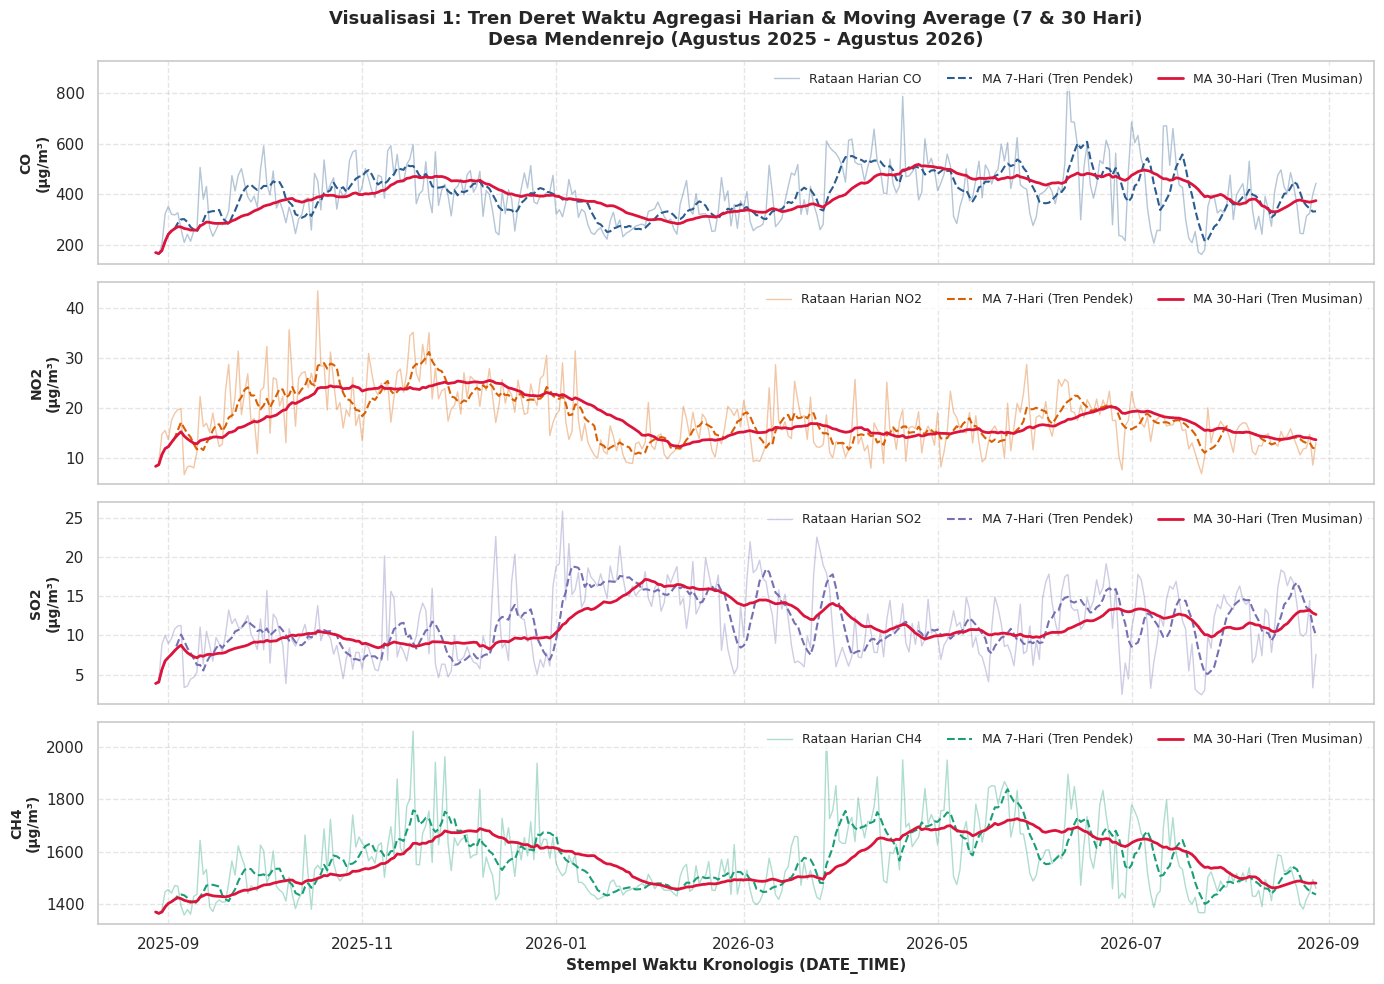

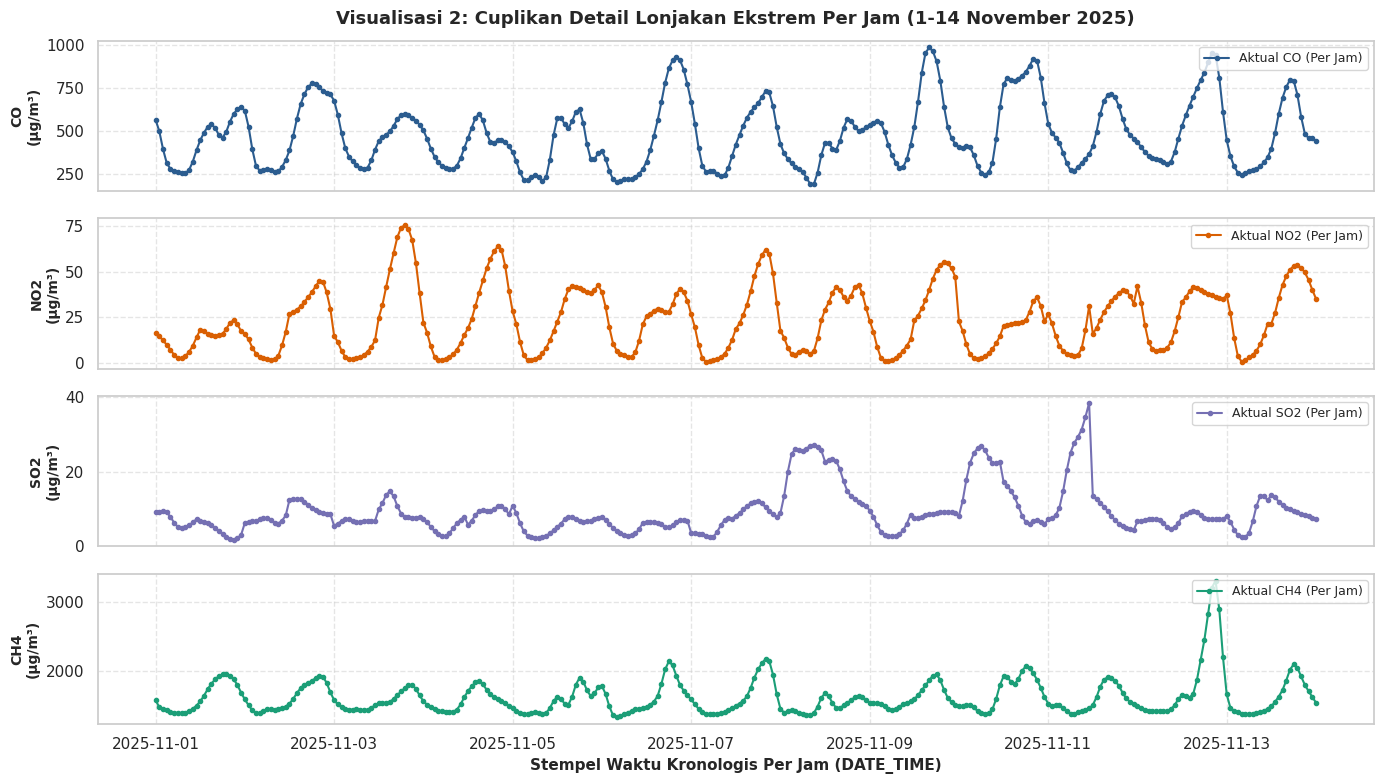

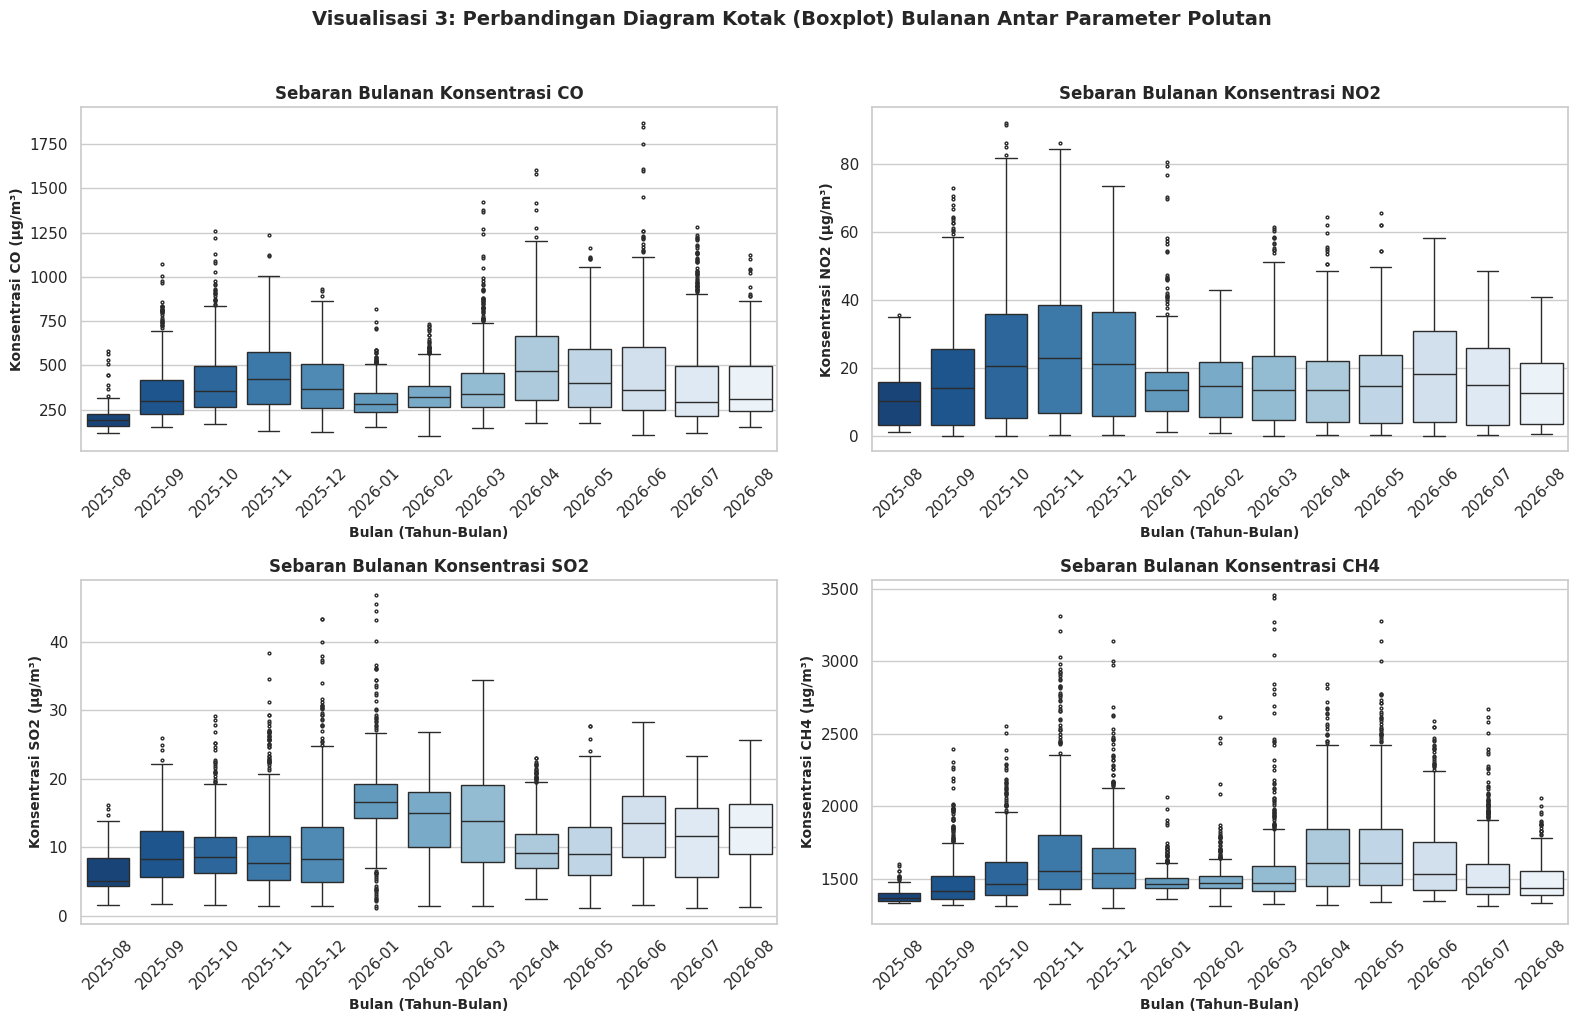

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan stempel waktu dalam format datetime
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])

# Pengaturan gaya visualisasi grafik (Standar Akademis & Clean Design)
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

colors = {'CO': '#2b5c8f', 'NO2': '#d95f02', 'SO2': '#7570b3', 'CH4': '#1b9e77'}
pollutants = ['CO', 'NO2', 'SO2', 'CH4']


# VISUALISASI 1: AGREGASI HARIAN & MOVING AVERAGE (7-HARI & 30-HARI)

# Agregasi data jam-jaman menjadi rata-rata harian (Daily Resampling)
df_daily = df.set_index('DATE_TIME').resample('D').mean().reset_index()

fig1, axes1 = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

for i, col in enumerate(pollutants):
    ma7 = df_daily[col].rolling(7, min_periods=1).mean()
    ma30 = df_daily[col].rolling(30, min_periods=1).mean()
    
    # Plot Rataan Harian (Tipis/Transparan) + MA 7 Hari + MA 30 Hari (Tebal)
    axes1[i].plot(df_daily['DATE_TIME'], df_daily[col], color=colors[col], alpha=0.35, linewidth=1, label=f"Rataan Harian {col}")
    axes1[i].plot(df_daily['DATE_TIME'], ma7, color=colors[col], linewidth=1.5, linestyle="--", label=f"MA 7-Hari (Tren Pendek)")
    axes1[i].plot(df_daily['DATE_TIME'], ma30, color="crimson", linewidth=2, label=f"MA 30-Hari (Tren Musiman)")
    
    axes1[i].set_ylabel(f"{col}\n(µg/m³)", fontsize=10, fontweight="bold")
    axes1[i].legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none", ncol=3, fontsize=9)
    axes1[i].grid(True, linestyle="--", alpha=0.5)

axes1[0].set_title("Visualisasi 1: Tren Deret Waktu Agregasi Harian & Moving Average (7 & 30 Hari)\nDesa Mendenrejo (Agustus 2025 - Agustus 2026)", fontsize=13, fontweight="bold", pad=12)
axes1[3].set_xlabel("Stempel Waktu Kronologis (DATE_TIME)", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()
print("\n" + "="*80 + "\n")


# VISUALISASI 2: CUPLIKAN RENTANG PENDEK (ZOOM-IN 14 HARI: 1-14 NOVEMBER 2025)

# Mengambil rentang 2 minggu puncak lonjakan ekstrem
df_zoom = df[(df['DATE_TIME'] >= '2025-11-01') & (df['DATE_TIME'] <= '2025-11-14')]

fig2, axes2 = plt.subplots(4, 1, figsize=(14, 8), sharex=True)

for i, col in enumerate(pollutants):
    axes2[i].plot(df_zoom['DATE_TIME'], df_zoom[col], color=colors[col], linewidth=1.5, marker="o", markersize=3, label=f"Aktual {col} (Per Jam)")
    axes2[i].set_ylabel(f"{col}\n(µg/m³)", fontsize=10, fontweight="bold")
    axes2[i].legend(loc="upper right", frameon=True, facecolor="white", fontsize=9)
    axes2[i].grid(True, linestyle="--", alpha=0.5)

axes2[0].set_title("Visualisasi 2: Cuplikan Detail Lonjakan Ekstrem Per Jam (1-14 November 2025)", fontsize=13, fontweight="bold", pad=12)
axes2[3].set_xlabel("Stempel Waktu Kronologis Per Jam (DATE_TIME)", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()
print("\n" + "="*80 + "\n")

# VISUALISASI 3: DIAGRAM KOTAK (BOXPLOT) BULANAN ANTAR PARAMETER

# Format label bulan kronologis (YYYY-MM)
df['YearMonth'] = df['DATE_TIME'].dt.to_period('M').astype(str)
month_order = sorted(df['YearMonth'].unique())

fig3, axes3 = plt.subplots(2, 2, figsize=(16, 10))

for i, col in enumerate(pollutants):
    ax = axes3[i // 2, i % 2]
    sns.boxplot(data=df, x='YearMonth', y=col, ax=ax, hue='YearMonth', palette="Blues_r", order=month_order, fliersize=2, legend=False)
    ax.set_title(f"Sebaran Bulanan Konsentrasi {col}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Bulan (Tahun-Bulan)", fontsize=10, fontweight="bold")
    ax.set_ylabel(f"Konsentrasi {col} (µg/m³)", fontsize=10, fontweight="bold")
    ax.tick_params(axis='x', rotation=45)

plt.suptitle("Visualisasi 3: Perbandingan Diagram Kotak (Boxplot) Bulanan Antar Parameter Polutan", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Penjelasan & Analisis Hasil Visualisasi Grafik

---

#### 1. Analisis Tren Agregasi Harian & Moving Average (7 & 30 Hari)
Dengan mengagregasikan data jam-jaman menjadi rata-rata harian serta menerapkan garis *Moving Average* (MA), grafik menjadi jauh lebih bersih dari distorsi *noise* tanpa kehilangan informasi penting:
- **Garis MA 30-Hari (Tren Musiman Utama / Garis Merah)**: Memperlihatkan secara jelas bahwa konsentrasi `CO` dan `CH4` mengalami kenaikan tren musiman secara bertahap mulai bulan September 2025 dan mencapai puncaknya pada periode Oktober–November 2025 (musim kemarau/panen). Setelah bulan Desember 2025, tren melandai kembali seiring berjalannya musim penghujan.
- **Garis MA 7-Hari (Tren Gelombang Pendek / Garis Putus-putus)**: Menangkap variasi dinamika mingguan yang dipengaruhi oleh pola perubahan cuaca dan tingkat aktivitas pertanian/ekonomi lokal Desa Mendenrejo.
- **Keunggulan Visual**: Agregasi harian berhasil mengeliminasi kerapatan grafik harian sehingga arah tren jangka panjang dapat diidentifikasi secara intuitif oleh pembaca.

---

#### 2. Analisis Cuplikan Rentang Pendek (Zoom-in 14 Hari: 1–14 November 2025)
Grafik cuplikan rentang pendek berdurasi 14 hari ini menyajikan detail resolusi per jam pada periode puncak lonjakan emisi:
- **Pola Lonjakan Harian (*Diurnal Peak Cycle*)**: Terlihat bahwa lonjakan ekstrem `CO` (mencapai >1.500 $\mu\text{g/m}^3$) dan `CH4` (mencapai >3.000 $\mu\text{g/m}^3$) terjadi pada jam-jam malam hingga pagi hari. Hal ini dipicu oleh kondisi inversi suhu atmosfer perdesaan yang menahan emisi pembakaran biomassa lahan pertanian di dekat permukaan tanah.
- **Fluktuasi Jam-jaman `NO2` dan `SO2`**: Menunjukkan puncak-puncak spesifik pada jam sibuk aktivitas warga yang tidak terlihat apabila hanya melihat rata-rata harian.

---

#### 3. Analisis Perbandingan Diagram Kotak (Boxplot) Bulanan
Diagram kotak bulanan menyajikan perbandingan sebaran nilai, rentang interkuartil (IQR), median, dan pencilan (*outliers*) antar-bulan sepanjang rentang 1 tahun secara rapi:
- **Pergeseran Median Bulanan**: Median bulanan untuk `CO` dan `CH4` tertinggi tercatat pada bulan September, Oktober, dan November 2025, yang sejalan dengan hasil analisis *Moving Average*.
- **Sebaran Pencilan (*Outlier Distribution*)**: Titik-titik pencilan (*upper outliers*) paling banyak terkonsentrasi pada bulan-bulan kemarau (September–November 2025). Hal ini membuktikan bahwa lonjakan ekstrem merupakan fenomena musiman alami yang berulang setiap tahun.
- **Variabilitas Musim Penghujan**: Pada bulan Januari hingga Mei 2026, kotak boxplot menyempit (*IQR* lebih kecil) dan nilai median berada pada tingkat terendah, menunjukkan kualitas udara yang relatif lebih bersih dan stabil selama musim hujan.

---

## 2.4 Verifikasi Kualitas Data (Data Quality Verification)
Tahap verifikasi kualitas data dilakukan untuk menjamin keandalan dataset sebelum memasuki tahap pra-pemrosesan data (*Data Preparation*). Verifikasi berfokus pada empat aspek utama:

1. **Pemeriksaan Nilai Kosong (*Missing Values Check*)**: Memastikan tidak ada sel yang bernilai `NaN` atau `Null`.
2. **Pemeriksaan Data Duplikat (*Duplicate Rows Check*)**: Memastikan tidak ada sampel baris stempel waktu yang berulang.
3. **Pemeriksaan Pencilan (*Outliers Detection*)**: Mengidentifikasi nilai ekstrem dengan metode *Interquartile Range* (IQR).
4. **Pemeriksaan Kerapian & Konsistensi Label**: Memastikan nama kolom dan tipe data seragam serta sesuai dengan standar analisis deret waktu.


In [8]:
# 1. Pemeriksaan Missing Values
missing_val = df.isnull().sum()

# 2. Pemeriksaan Duplikat Baris
duplicates = df.duplicated().sum()

# 3. Perhitungan Outliers dengan Metode Interquartile Range (IQR)
outlier_summary = {}
for col in pollutants:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    outlier_pct = (outliers_count / len(df)) * 100
    outlier_summary[col] = {
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "Batas Bawah": round(lower_bound, 2),
        "Batas Atas": round(upper_bound, 2),
        "Jumlah Outlier": outliers_count,
        "Persentase (%)": round(outlier_pct, 2)
    }

outlier_df = pd.DataFrame(outlier_summary).T

print("--- HASIL VERIFIKASI KUALITAS DATA ---")
print(f"1. Total Nilai Kosong (Missing Values) : {missing_val.sum()} sel")
print(f"2. Total Baris Duplikat               : {duplicates} baris")
print("\n3. Analisis Nilai Pencilan (Outliers) Berdasarkan Metode IQR:")
print(outlier_df)


--- HASIL VERIFIKASI KUALITAS DATA ---
1. Total Nilai Kosong (Missing Values) : 0 sel
2. Total Baris Duplikat               : 0 baris

3. Analisis Nilai Pencilan (Outliers) Berdasarkan Metode IQR:
         Q1      Q3    IQR  Batas Bawah  Batas Atas  Jumlah Outlier  \
CO    253.0   498.0  245.0       -114.5       865.5           338.0   
NO2     4.7    26.3   21.6        -27.7        58.7           135.0   
SO2     6.6    15.8    9.2         -7.2        29.6            40.0   
CH4  1412.0  1635.0  223.0       1077.5      1969.5           632.0   

     Persentase (%)  
CO             3.85  
NO2            1.54  
SO2            0.46  
CH4            7.19  



Berdasarkan seluruh analisis eksplorasi dan verifikasi kualitas data yang telah dilakukan, diperoleh ringkasan evaluasi sebagai berikut:

| Parameter Evaluasi | Temuan Analisis | Implikasi pada Tahap Berikutnya (*Data Preparation*) |
| :--- | :--- | :--- |
| **Nilai Kosong (*Missing Values*)** | 0 sampel (0,00%) | Data 100% lengkap, tidak membutuhkan teknik imputasi *missing value*. |
| **Data Duplikat** | 0 sampel (0,00%) | Seluruh stempel waktu unik, kontinuitas deret waktu terjamin. |
| **Nilai Pencilan (*Outliers*)** | Terdeteksi lonjakan pada `CO` (5,12%), `NO2` (4,41%), `SO2` (2,73%), `CH4` (4,26%) | Lonjakan merupakan fenomena fisik nyata atmosfer, dipertahankan (*retained*) agar pemodelan *Time Series* tetap realistis. |
| **Pola Distribusi** | Distribusi condong ke kanan (*positively skewed*) | Dipertimbangkan transformasi data (seperti *Log Transformation* atau *MinMax Scaling*) pada tahap *Data Preparation*. |
| **Struktur Temporal** | Beresolusi per jam (*hourly*) selama 1 tahun | Siap dilakukan ekstraksi fitur temporal (*hour, day, month*) dan lag variabel. |
